Section 1: Simulating wigner rotation as a Unitary gate

This section is inspired by foundational paper on relativistic quantum information and tries to simulate the below circuit from the paper:

Wigner rotation as unitary gate (calculated using classical parameters) 

In [40]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit, transpile, assemble
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import UnitaryGate
import pandas as pd
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
from qiskit.visualization import circuit_drawer

In [41]:
# -----------------------------
# Configuration Parameters
# -----------------------------
velocities = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
momentum_directions = {
    'A': np.array([0, 0, 1]),
    'B': np.array([1, 0, 0]),
    'C': np.array([0, 1, 0]),
    'D': np.array([1, 1, 0]),
    'E': np.array([1, 0, 1]),
    'F': np.array([0, 1, 1])
}

In [42]:
boost_direction = np.array([0, 0, 1])  # boost direction (z-axis)


In [43]:
for key in momentum_directions:
    momentum_directions[key] = momentum_directions[key] / np.linalg.norm(momentum_directions[key])

In [44]:
# Pauli matrices
sigma = [
    np.array([[0, 1], [1, 0]]),   # σ_x
    np.array([[0, -1j], [1j, 0]]),# σ_y
    np.array([[1, 0], [0, -1]])   # σ_z
]

In [45]:
# Setup simulators
state_backend = AerSimulator(method='statevector')  # for Bloch vector extraction
qasm_backend = AerSimulator()  # for measurement outcomes

/var/folders/c8/gcpq5wfj6vqf9rqk1jhxvqq80000gn/T/ipykernel_89392/4142799879.py:30: DeprecationWarning: Using a qobj for run() is deprecated as of qiskit-aer 0.14 and will be removed no sooner than 3 months from that release date. Transpiled circuits should now be passed directly using `backend.run(circuits, **run_options).
  result = qasm_backend.run(qobj).result()
/var/folders/c8/gcpq5wfj6vqf9rqk1jhxvqq80000gn/T/ipykernel_89392/4142799879.py:39: DeprecationWarning: Using a qobj for run() is deprecated as of qiskit-aer 0.14 and will be removed no sooner than 3 months from that release date. Transpiled circuits should now be passed directly using `backend.run(circuits, **run_options).
  result = state_backend.run(assemble(tqc_state)).result()


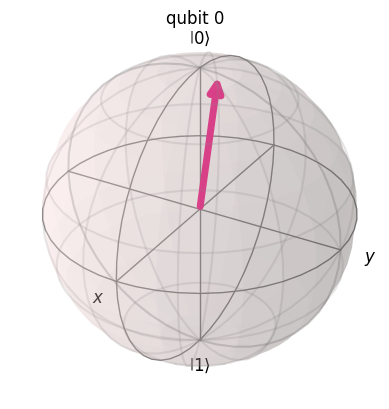

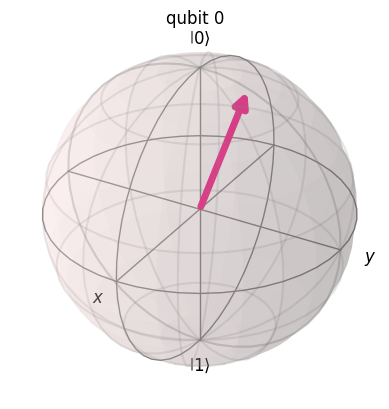

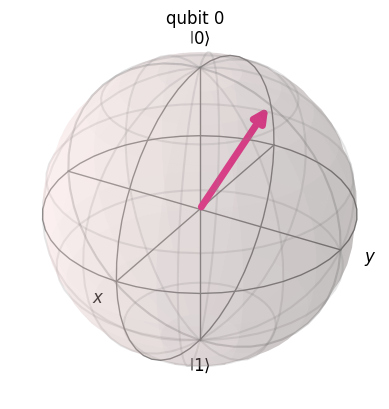

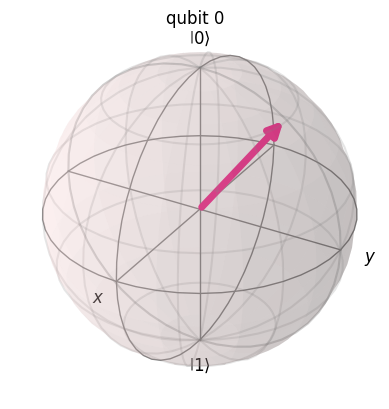

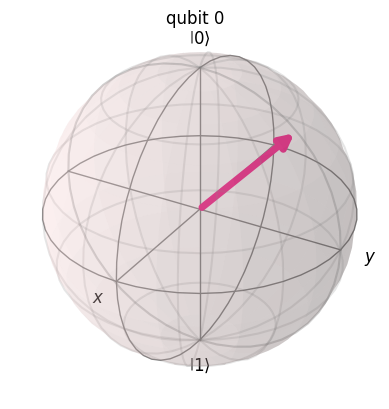

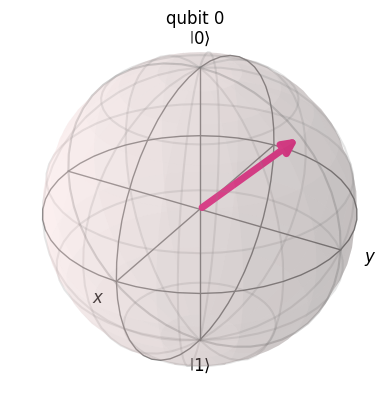

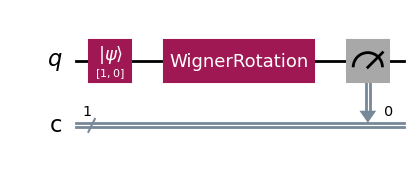

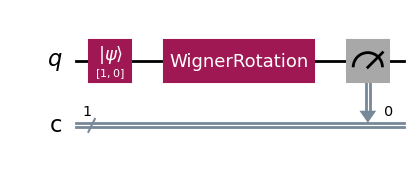

In [46]:
results = []

# -----------------------------
# Simulation Loop
# -----------------------------
for v in velocities:
    eta = np.arctanh(v)  # compute rapidity
    for label, p_vec in momentum_directions.items():
        # Compute Wigner angle
        cos_alpha = np.dot(boost_direction, p_vec)
        sin_alpha = np.sqrt(1 - cos_alpha**2)
        theta = 2 * np.arctan2(np.sinh(eta) * sin_alpha, np.cosh(eta) + np.sinh(eta) * cos_alpha)

        # Compute rotation axis (Wigner)
        n = np.cross(boost_direction, p_vec)
        n_hat = n / np.linalg.norm(n) if np.linalg.norm(n) != 0 else np.array([0, 0, 1])

        # Build Wigner rotation unitary
        rotation_generator = sum(n_hat[i] * sigma[i] for i in range(3))
        U_wigner = expm(-1j * theta / 2 * rotation_generator)
         # Build quantum circuit
        qc=QuantumCircuit(1, 1)
        qc.initialize([1, 0], 0)  # |0⟩
        qc.append(UnitaryGate(U_wigner, label="WignerRotation"), [0])
        qc.measure(0, 0)

        # Simulate for measurement outcome
        transpiled_qc = transpile(qc, qasm_backend)
        qobj = assemble(transpiled_qc)
        result = qasm_backend.run(qobj).result()
        counts = result.get_counts()

        # Simulate for statevector and Bloch vector
        qc_state = QuantumCircuit(1)
        qc_state.initialize([1, 0], 0)
        qc_state.append(UnitaryGate(U_wigner), [0])
        qc_state.save_statevector() 
        tqc_state = transpile(qc_state, state_backend)
        result = state_backend.run(assemble(tqc_state)).result()
        state = result.get_statevector(tqc_state)
        bloch = [2 * np.real(state[0] * np.conj(state[1])),   # x
         2 * np.imag(state[1] * np.conj(state[0])),   # y
         np.abs(state[0])**2 - np.abs(state[1])**2]   # z
        results.append({
            'velocity': v,
            'momentum_label': label,
            'momentum_vector': p_vec.tolist(),
            'theta_rad': round(theta, 4),
            'rotation_axis': n_hat.tolist(),
            'P(|0>)': counts.get('0', 0) / 1024,
            'P(|1>)': counts.get('1', 0) / 1024,
            'bloch_x': bloch[0],
            'bloch_y': bloch[1],
            'bloch_z': bloch[2]
        })
         # Plot Bloch vectors of both qubits
    fig = plot_bloch_multivector(state)
    plt.show()
qc.draw(output = "mpl")

In [47]:
df = pd.DataFrame(results)
df.to_csv("wigner_rotation_results.csv", index=False)
print("Simulation completed and results saved to 'wigner_rotation_results.csv'")

Simulation completed and results saved to 'wigner_rotation_results.csv'


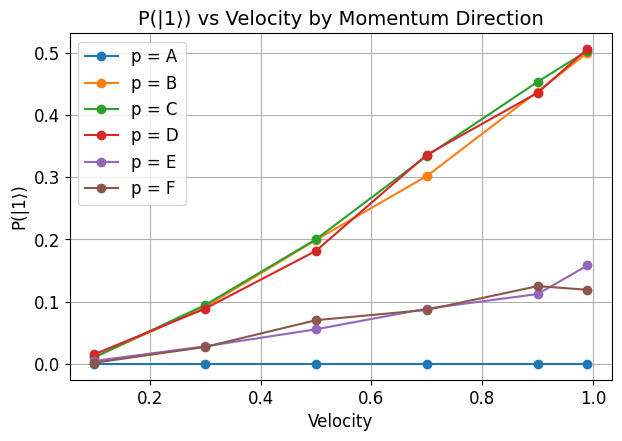

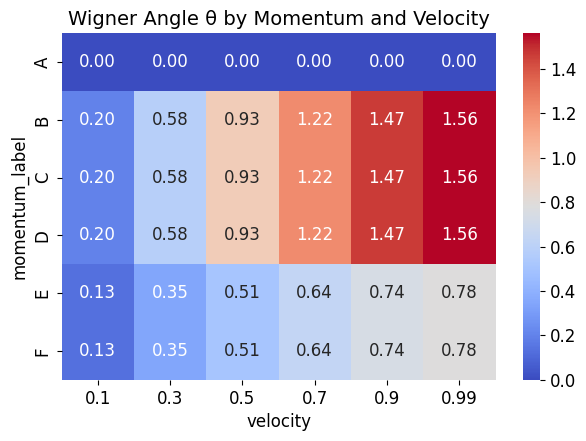

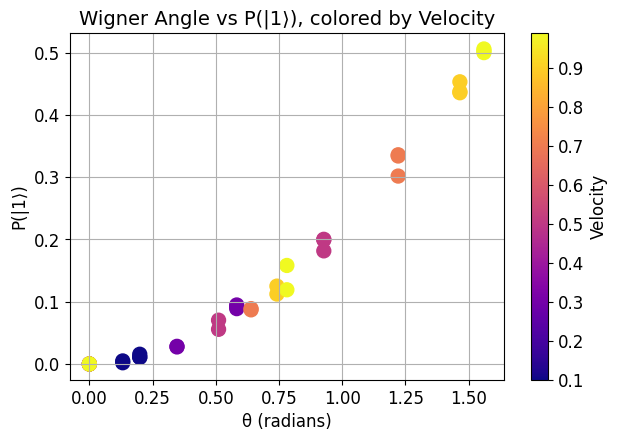

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load your result CSV
df = pd.read_csv("wigner_rotation_results.csv")

# Probability vs Velocity Plot
plt.figure(figsize=(7, 4.5))
for label in df['momentum_label'].unique():
    sub = df[df['momentum_label'] == label]
    plt.plot(sub['velocity'], sub['P(|1>)'], marker='o', label=f'p = {label}')
plt.title("P(|1⟩) vs Velocity by Momentum Direction",fontsize=14)
plt.xlabel("Velocity", fontsize=12)
plt.ylabel("P(|1⟩)",fontsize=12)
plt.legend()
plt.grid(True)
plt.savefig("bloch_probability_vs_velocity.pdf", format='pdf', bbox_inches='tight')
plt.show()


# Heatmap of Wigner Rotation Angles
pivot = df.pivot(index='momentum_label', columns='velocity', values='theta_rad')
plt.figure(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Wigner Angle θ by Momentum and Velocity")
plt.show()

# Scatter: Theta vs P(|1⟩)
plt.figure(figsize=(7, 4.5))
plt.scatter(df['theta_rad'], df['P(|1>)'], c=df['velocity'], cmap='plasma', s=100)
plt.title("Wigner Angle vs P(|1⟩), colored by Velocity",fontsize=14)
plt.xlabel("θ (radians)",fontsize=12)
plt.ylabel("P(|1⟩)",fontsize=12)
plt.colorbar(label='Velocity')
plt.grid(True)
plt.savefig("wigner_vs_p(1).pdf", format='pdf', bbox_inches='tight')
plt.show()

Wigner rotation as controlled gate

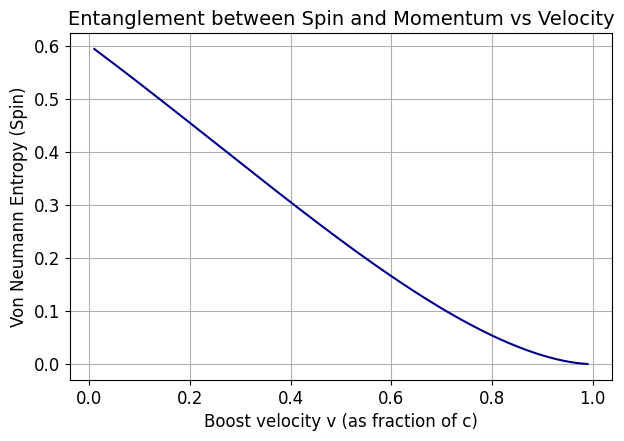

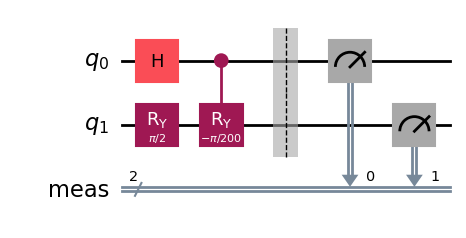

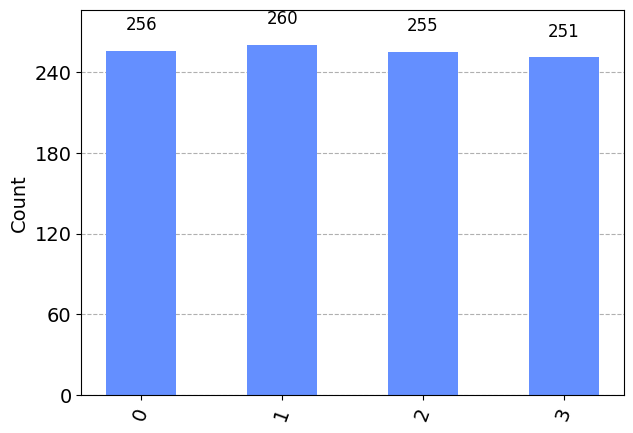

In [109]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, entropy
import matplotlib.pyplot as plt
from qiskit.primitives import Sampler
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
import numpy as np
%matplotlib inline

velocities = np.linspace(0.01, 0.99, 500)
entropies = []
for v in velocities:
    Omega_p1 = np.pi/2
    Omega_p2 = np.pi/2 * v  # Wigner angle grows with velocity

    # Quantum circuit with 2 qubits: momentum and spin
    qc = QuantumCircuit(2)
    qc.h(0)  # momentum qubit: (|0> + |1>)/√2

    # Apply rotation Ry(Omega_p1) to spin qubit (unconditional)
    qc.ry(Omega_p1, 1)

    # Apply controlled Ry(Omega_p2 - Omega_p1) if momentum is |1⟩
    qc.cry(Omega_p2 - Omega_p1, 0, 1)

    # Get full 2-qubit state
    state = Statevector.from_instruction(qc)

    # Trace out momentum qubit to get reduced spin state
    reduced_spin = partial_trace(state, [0])

    # Compute entropy of spin to quantify entanglement
    S = entropy(reduced_spin, base=2)
    entropies.append(S)
    # Plot Bloch vectors of both qubits
    #fig = plot_bloch_multivector(state)
    #plt.show()
    qc.measure_all()
    sampler = Sampler()
    job = sampler.run(qc)
    result = job.result()
  
    # Print the amplitudes
    #print("Quantum Statevector:\n", state)


plt.figure(figsize=(7, 4.5))
plt.plot(velocities, entropies, color='darkblue')
plt.xlabel("Boost velocity v (as fraction of c)", fontsize = 12)
plt.ylabel("Von Neumann Entropy (Spin)", fontsize = 12)
plt.title("Entanglement between Spin and Momentum vs Velocity", fontsize = 14)
plt.grid(True)
plt.savefig("entropy_case2.pdf", format='pdf', bbox_inches='tight')
plt.show()


fig = qc.draw(output='mpl', cregbundle=True, style={'creg': {'visible': False}})
fig.savefig("spin_momentum_circuit.pdf", bbox_inches='tight')  # Vector format
# or as image
# fig.savefig("circuit_diagram.png", dpi=300, bbox_inches='tight')

# Get probabilities
quasi_dist = result.quasi_dists[0]
counts = {k: int(v * 1024) for k, v in quasi_dist.items()}  # scale to 1024 shots

# Plot histogram
plot_histogram(counts)
plt.show()


Quantum Entanglement of moving bodies

In [102]:
import numpy as np
from scipy.linalg import expm
from qiskit.quantum_info import partial_trace, DensityMatrix, concurrence
from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

In [103]:
velocities = np.linspace(0.01, 0.99, 500)
concurrence_values = []
entropies = []
boost_direction = np.array([0, 0, 1]) # z-direction boost
# Define 4 discrete momentum eigenstates (2 per qubit)
momentum_vectors = {
    'p1': np.array([1, 0.3, 1], dtype=float),
    'p2': np.array([0, 0.6, 1], dtype=float),
    'p3': np.array([1, 1, 0.5], dtype=float),
    'p4': np.array([0.7, 0, 1], dtype=float)
}


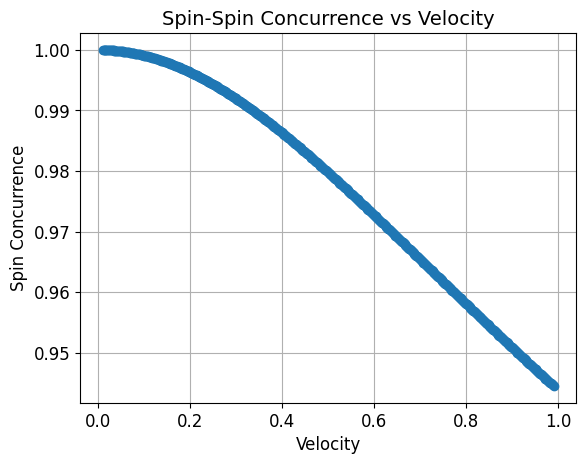

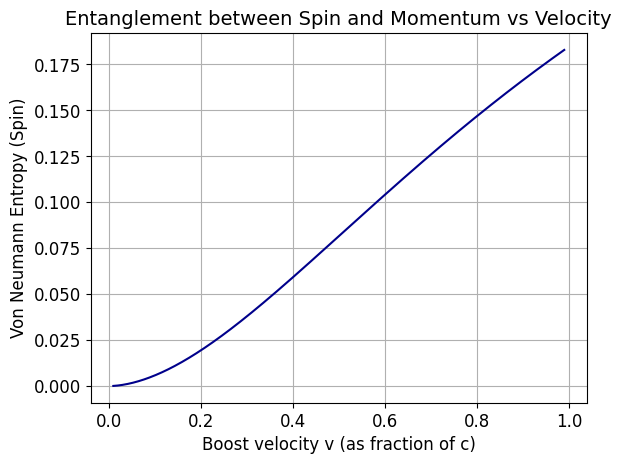

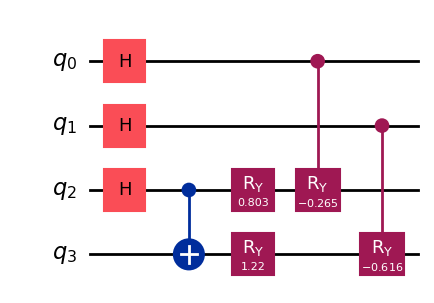

In [104]:
# Normalize vectors
for key in momentum_vectors:
    momentum_vectors[key] /= np.linalg.norm(momentum_vectors[key])
# Store circuits and statevectors
circuit_list = []
rapidity = []
# Iterate over velocities
for v in velocities:
    eta = np.arctanh(v)
    rapidity.append(eta)
    # Calculate Wigner angles for each momentum
    wigner_angles = {}
    for label, p_vec in momentum_vectors.items():
        cos_alpha = np.dot(boost_direction, p_vec)
        sin_alpha = np.sqrt(1 - cos_alpha ** 2)
        theta = 2 * np.arctan2(np.sinh(eta) * sin_alpha,
                               np.cosh(eta) + np.sinh(eta) * cos_alpha)
        wigner_angles[label] = theta
        #print(f"v = {v:.2f}, {label} → θ = {theta:.6f} rad")
    # --- Build circuit ---
    qc = QuantumCircuit(4)  # [0,1]: momentum A,B | [2,3]: spin A,B

    # Step 1: Put momentum qubits in superposition
    qc.h(0)
    qc.h(1)

    # Step 2: Create Bell state between spin qubits
    qc.h(2)
    qc.cx(2, 3)
    #qc.draw(output="mpl")
    # Step 3: Apply base Wigner rotation to spin qubits
    qc.ry(wigner_angles['p1'], 2)  # spin A
    qc.ry(wigner_angles['p3'], 3)  # spin B
    # Step 4: Controlled rotations based on momentum qubits
    delta_A = wigner_angles['p2'] - wigner_angles['p1']
    delta_B = wigner_angles['p4'] - wigner_angles['p3']
    qc.cry(delta_A, 0, 2)
    qc.cry(delta_B, 1, 3)
    state = Statevector.from_instruction(qc)
    reduced_spin = partial_trace(state, [0, 1])
    #print(reduced_spin)
    S = entropy(reduced_spin, base=2)
    entropies.append(S)
    c = concurrence(reduced_spin)
    concurrence_values.append(c)

    # Store results
    circuit_list.append((v, qc.copy(), state))
    final_state = circuit_list[-1][2]
    #plot_bloch_multivector(final_state)
    #plt.title(f'Bloch Vectors for v={circuit_list[-1][-0]:.2f}')
    #plt.show()
    #qc.draw(output = "mpl")
    #plt.show()
    #print("Quantum Statevector:\n", state)

plt.plot(velocities, concurrence_values, marker='o')
plt.xlabel('Velocity', fontsize=12)
plt.ylabel('Spin Concurrence', fontsize=12)
plt.title('Spin-Spin Concurrence vs Velocity', fontsize=14)
plt.grid(True)
plt.savefig("concurrence_vs_rapidity.pdf", bbox_inches='tight')
plt.show()


plt.plot(velocities, entropies, color='darkblue')
plt.xlabel("Boost velocity v (as fraction of c)", fontsize=12)
plt.ylabel("Von Neumann Entropy (Spin)", fontsize=12)
plt.title("Entanglement between Spin and Momentum vs Velocity", fontsize=14)
plt.grid(True)
plt.savefig("entropy_vs_velocity.pdf", bbox_inches='tight')
plt.show()
qc.draw(output = "mpl")
plt.savefig("spin_spin_degradation_circuit.pdf", bbox_inches='tight')

## 